## 04 — Train Wait Time Prediction Model

Target: **Wait Time (Minutes)** — regression problem  
Models compared: Linear Regression (baseline) → Random Forest → XGBoost (tuned)  
Metrics: RMSE, MAE, R²

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from xgboost import XGBRegressor

from feature_engineering import prepare_with_features

plt.style.use('dark_background')
ACCENT = '#3b82f6'
PALETTE = ['#3b82f6', '#22c55e', '#f97316', '#a855f7']
print('Libraries loaded')

Libraries loaded


### 1. Load Data & Apply Feature Engineering

In [2]:
splits = prepare_with_features()
X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_wait_train']
y_test  = splits['y_wait_test']
feature_names = splits['feature_names']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {len(feature_names)}')
print(f'Target range     : {y_train.min():.1f} – {y_train.max():.1f} minutes')
print(f'Target mean      : {y_train.mean():.1f} minutes')

Training samples : 4000
Test samples     : 1000
Features         : 16
Target range     : 4.0 – 429.0 minutes
Target mean      : 81.9 minutes


### 2. Baseline — Linear Regression

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'Linear Regression  →  RMSE: {rmse_lr:.2f}  MAE: {mae_lr:.2f}  R²: {r2_lr:.4f}')

Linear Regression  →  RMSE: 28.27  MAE: 20.58  R²: 0.8282


### 3. Random Forest Regressor

In [4]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'Random Forest  →  RMSE: {rmse_rf:.2f}  MAE: {mae_rf:.2f}  R²: {r2_rf:.4f}')

Random Forest  →  RMSE: 18.13  MAE: 12.36  R²: 0.9294


### 4. XGBoost Regressor

In [5]:
xgb = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f'XGBoost (default)  →  RMSE: {rmse_xgb:.2f}  MAE: {mae_xgb:.2f}  R²: {r2_xgb:.4f}')

XGBoost (default)  →  RMSE: 19.61  MAE: 13.46  R²: 0.9173


### 5. Cross-Validation (5-Fold)

LinearRegression      CV RMSE: 28.227 ± 0.427
RandomForest          CV RMSE: 18.728 ± 0.529
XGBoost               CV RMSE: 18.873 ± 0.548


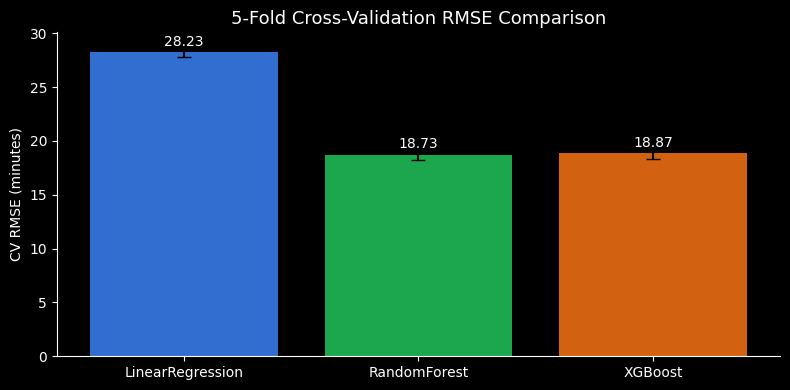

In [6]:
models_cv = {
    'LinearRegression': lr,
    'RandomForest': rf,
    'XGBoost': xgb,
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results[name] = -scores
    print(f'{name:<20}  CV RMSE: {-scores.mean():.3f} ± {scores.std():.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
bars = ax.bar(names, means, color=PALETTE[:3], yerr=stds, capsize=5, alpha=0.85)
ax.set_ylabel('CV RMSE (minutes)', color='white')
ax.set_title('5-Fold Cross-Validation RMSE Comparison', color='white', fontsize=13)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 6. Hyperparameter Tuning — XGBoost GridSearchCV

In [7]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print('\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV RMSE: {-grid_search.best_score_:.3f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best Parameters:
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 200
  subsample: 0.8

Best CV RMSE: 16.667


### 7. Final Model Evaluation

In [8]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb, rmse_best],
    'MAE':   [mae_lr,  mae_rf,  mae_xgb,  mae_best],
    'R²':    [r2_lr,   r2_rf,   r2_xgb,   r2_best],
})
summary = summary.sort_values('RMSE')
summary[['RMSE','MAE','R²']] = summary[['RMSE','MAE','R²']].round(4)
print(summary.to_string(index=False))

            Model    RMSE     MAE     R²
  XGBoost (tuned) 16.7890 11.5084 0.9394
    Random Forest 18.1279 12.3622 0.9294
XGBoost (default) 19.6104 13.4579 0.9173
Linear Regression 28.2743 20.5800 0.8282


### 8. Feature Importance

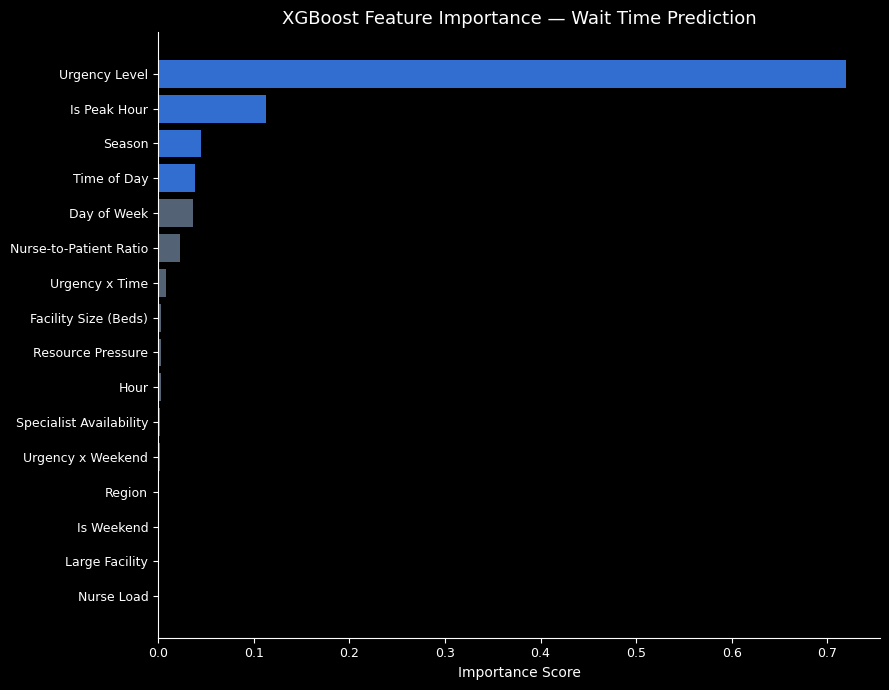


Top 5 features:
      feature  importance
Urgency Level    0.719028
 Is Peak Hour    0.112704
       Season    0.045090
  Time of Day    0.038755
  Day of Week    0.036965


In [9]:
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [ACCENT if imp > fi_df['importance'].quantile(0.75) else '#64748b' for imp in fi_df['importance']]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors, alpha=0.85)
ax.set_xlabel('Importance Score', color='white')
ax.set_title('XGBoost Feature Importance — Wait Time Prediction', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(fi_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

### 9. Residuals Analysis

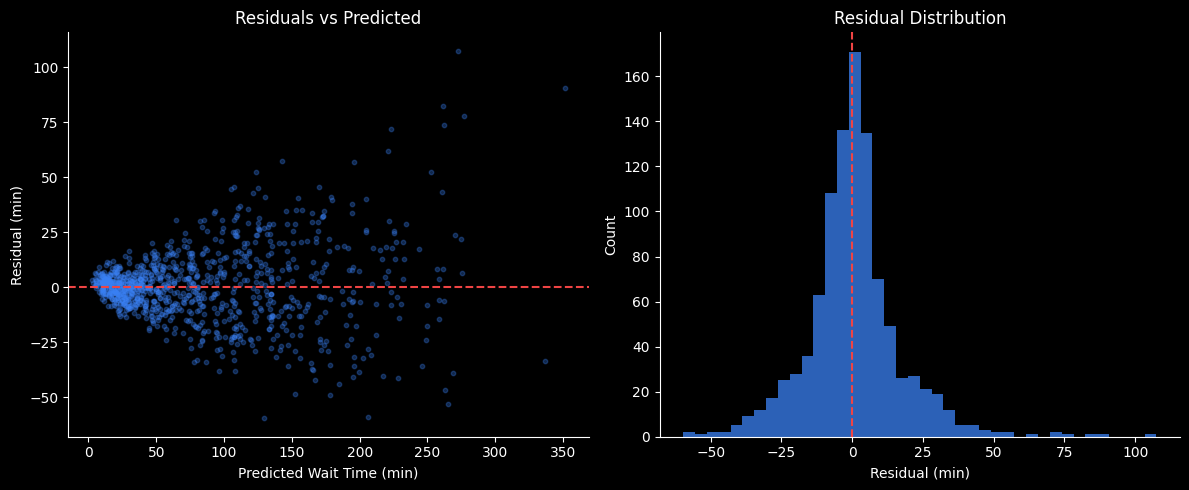

Residual mean  : 0.5793
Residual std   : 16.7874
Max overpredict: -59.70 min
Max underpredict: 107.48 min


In [10]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=10, color=ACCENT)
axes[0].axhline(0, color='#ef4444', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Wait Time (min)', color='white')
axes[0].set_ylabel('Residual (min)', color='white')
axes[0].set_title('Residuals vs Predicted', color='white', fontsize=12)
axes[0].tick_params(colors='white')
axes[0].spines[['top','right']].set_visible(False)

# Residual distribution
axes[1].hist(residuals, bins=40, color=ACCENT, alpha=0.75, edgecolor='none')
axes[1].axvline(0, color='#ef4444', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (min)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_title('Residual Distribution', color='white', fontsize=12)
axes[1].tick_params(colors='white')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Residual mean  : {residuals.mean():.4f}')
print(f'Residual std   : {residuals.std():.4f}')
print(f'Max overpredict: {residuals.min():.2f} min')
print(f'Max underpredict: {residuals.max():.2f} min')

### 10. Actual vs Predicted Scatter

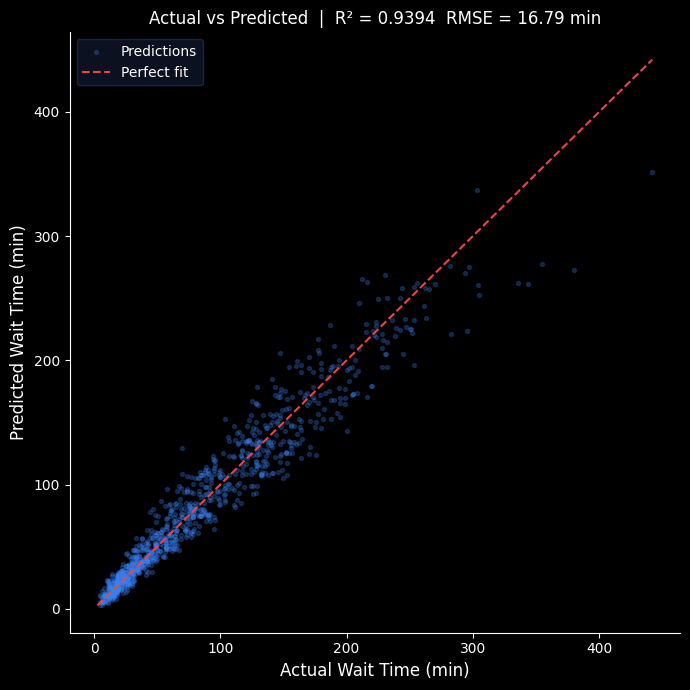

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred_best, alpha=0.25, s=8, color=ACCENT, label='Predictions')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, color='#ef4444', linewidth=1.5, linestyle='--', label='Perfect fit')
ax.set_xlabel('Actual Wait Time (min)', color='white', fontsize=12)
ax.set_ylabel('Predicted Wait Time (min)', color='white', fontsize=12)
ax.set_title(f'Actual vs Predicted  |  R² = {r2_best:.4f}  RMSE = {rmse_best:.2f} min',
             color='white', fontsize=12)
ax.legend(facecolor='#0f1629', edgecolor='#1e2d4a', labelcolor='white')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 11. Save Best Model

In [12]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

save_path = os.path.join(models_dir, 'wait_time_model.pkl')
joblib.dump({'model': best_model, 'feature_names': feature_names}, save_path)

print(f'Model saved: {save_path}')
print(f'\n--- Final Metrics ---')
print(f'RMSE : {rmse_best:.3f} minutes')
print(f'MAE  : {mae_best:.3f} minutes')
print(f'R²   : {r2_best:.4f}')
print(f'\nFeatures used: {len(feature_names)}')
print(feature_names)

Model saved: ..\models\wait_time_model.pkl

--- Final Metrics ---
RMSE : 16.789 minutes
MAE  : 11.508 minutes
R²   : 0.9394

Features used: 16
['Urgency Level', 'Time of Day', 'Day of Week', 'Season', 'Region', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Is Weekend', 'Hour', 'Nurse Load', 'Is Peak Hour', 'Resource Pressure', 'Urgency x Time', 'Urgency x Weekend', 'Large Facility']
